# 📊 RiskPulse Finance AI — Exploratory Data Analysis

Comprehensive EDA on the mental health text dataset used for financial stress risk modelling.

In [5]:
import sys
!{sys.executable} -m pip install wordcloud

In [6]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from data_preprocessing import load_and_clean, LABEL_MAP, CLASSES

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'text.color':       '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#30363d',
    'grid.alpha':       0.4,
})
PALETTE = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Inspect Data

In [7]:
df = load_and_clean('../data/dataset.csv')
print(f'Shape: {df.shape}')
df.head()

2026-04-17 10:35:56,882 [INFO] Loading dataset from ../data/dataset.csv
2026-04-17 10:35:57,557 [INFO] Dropped 362 rows with missing text (52681 remain)
2026-04-17 10:35:57,589 [INFO] After dedup: 51073 rows
2026-04-17 10:35:59,439 [INFO] Final dataset shape: (51063, 3)
2026-04-17 10:35:59,467 [INFO] Class distribution:
label
Depression    30519
Normal        16032
Anxiety        3617
Other           895


Shape: (51063, 3)


,text,label,clean_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,Anxiety,i've shifted my focus to something else but i'...
4,"I'm restless and restless, it's been a month n...",Anxiety,i'm restless and restless it's been a month no...


## 2. Missing Value Check

In [8]:
raw = pd.read_csv('../data/dataset.csv')
print('=== Raw Missing Values ===')
print(raw.isnull().sum())
print(f'\nTotal missing: {raw.isnull().sum().sum()}')
print(f'Missing text rows: {raw["statement"].isnull().sum()}')

=== Raw Missing Values ===
Unnamed: 0      0
statement     362
status          0
dtype: int64

Total missing: 362
Missing text rows: 362


## 3. Class Distribution

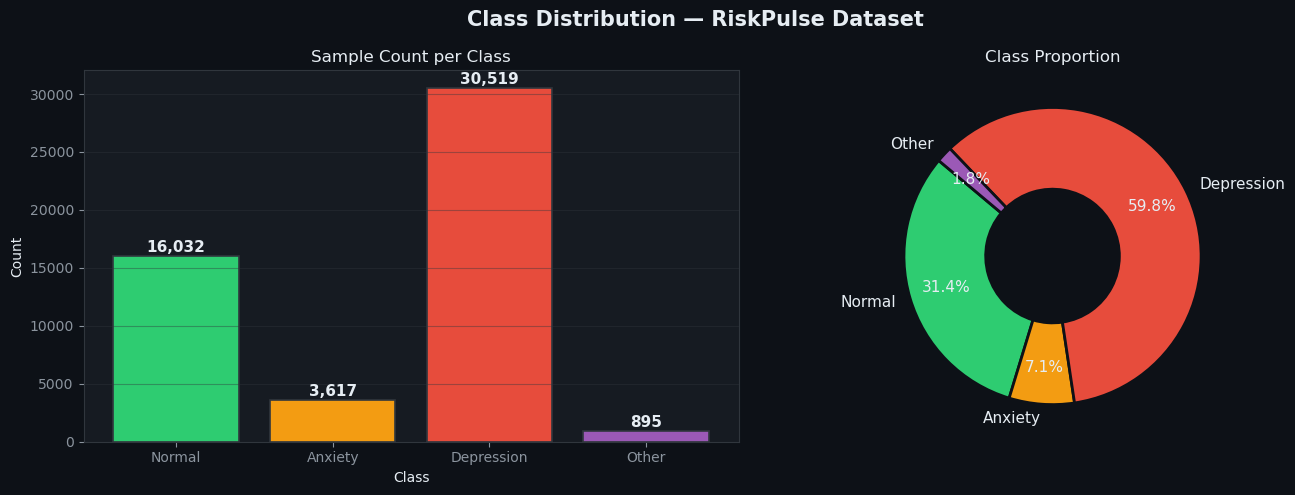

label
Normal        16032
Anxiety        3617
Depression    30519
Other           895


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — RiskPulse Dataset', fontsize=15, fontweight='bold')

counts = df['label'].value_counts().reindex(CLASSES)

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=PALETTE, edgecolor='#30363d', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Sample Count per Class', fontsize=12)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y')

# Pie chart
wedge_props = dict(width=0.55, edgecolor='#0d1117', linewidth=2)
axes[1].pie(counts.values, labels=counts.index, colors=PALETTE,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=wedge_props, pctdistance=0.75,
            textprops={'color': '#e6edf3', 'fontsize': 11})
axes[1].set_title('Class Proportion', fontsize=12)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts.to_string())

## 4. Text Length Distribution

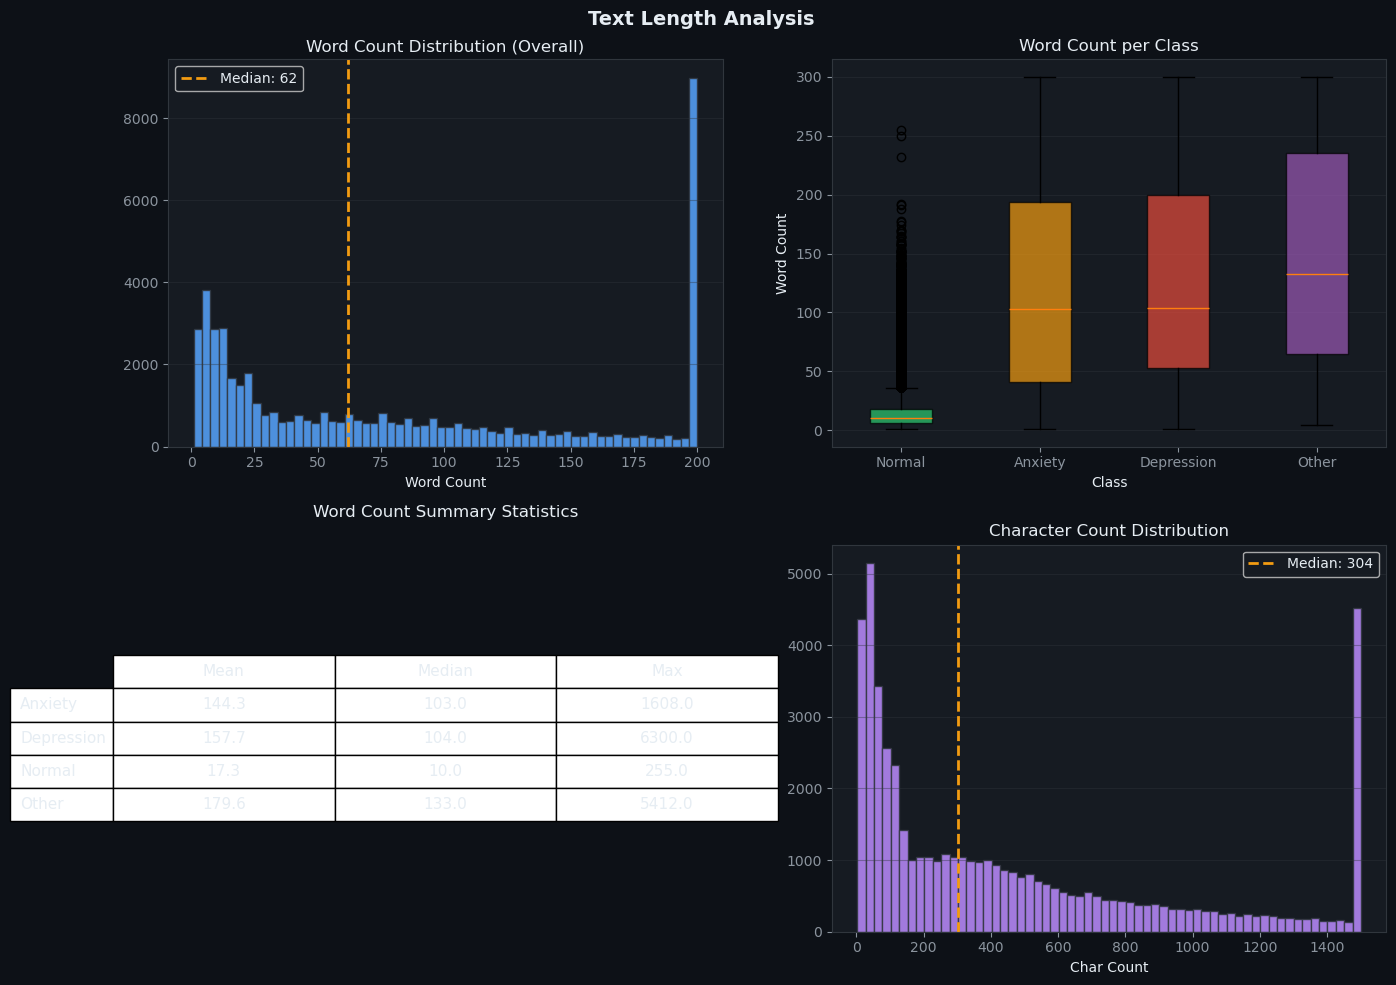

In [10]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_text'].apply(len)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Text Length Analysis', fontsize=14, fontweight='bold')

# Overall word count distribution
axes[0,0].hist(df['word_count'].clip(upper=200), bins=60, color='#58a6ff', edgecolor='#30363d', alpha=0.85)
axes[0,0].axvline(df['word_count'].median(), color='#f39c12', linestyle='--', linewidth=2, label=f'Median: {df["word_count"].median():.0f}')
axes[0,0].set_title('Word Count Distribution (Overall)')
axes[0,0].set_xlabel('Word Count')
axes[0,0].legend()
axes[0,0].grid(axis='y')

# Per-class boxplot
class_data = [df[df['label'] == c]['word_count'].clip(upper=300).values for c in CLASSES]
bp = axes[0,1].boxplot(class_data, labels=CLASSES, patch_artist=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0,1].set_title('Word Count per Class')
axes[0,1].set_xlabel('Class')
axes[0,1].set_ylabel('Word Count')
axes[0,1].grid(axis='y')

# Summary stats table
stats = df.groupby('label')['word_count'].describe()[['mean','50%','max']].round(1)
axes[1,0].axis('off')
tbl = axes[1,0].table(cellText=stats.values, rowLabels=stats.index,
                       colLabels=['Mean','Median','Max'], loc='center',
                       cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)
axes[1,0].set_title('Word Count Summary Statistics', pad=20)

# Char count histogram
axes[1,1].hist(df['char_count'].clip(upper=1500), bins=60, color='#bc8cff', edgecolor='#30363d', alpha=0.85)
axes[1,1].axvline(df['char_count'].median(), color='#f39c12', linestyle='--', linewidth=2, label=f'Median: {df["char_count"].median():.0f}')
axes[1,1].set_title('Character Count Distribution')
axes[1,1].set_xlabel('Char Count')
axes[1,1].legend()
axes[1,1].grid(axis='y')

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Word Frequency Analysis

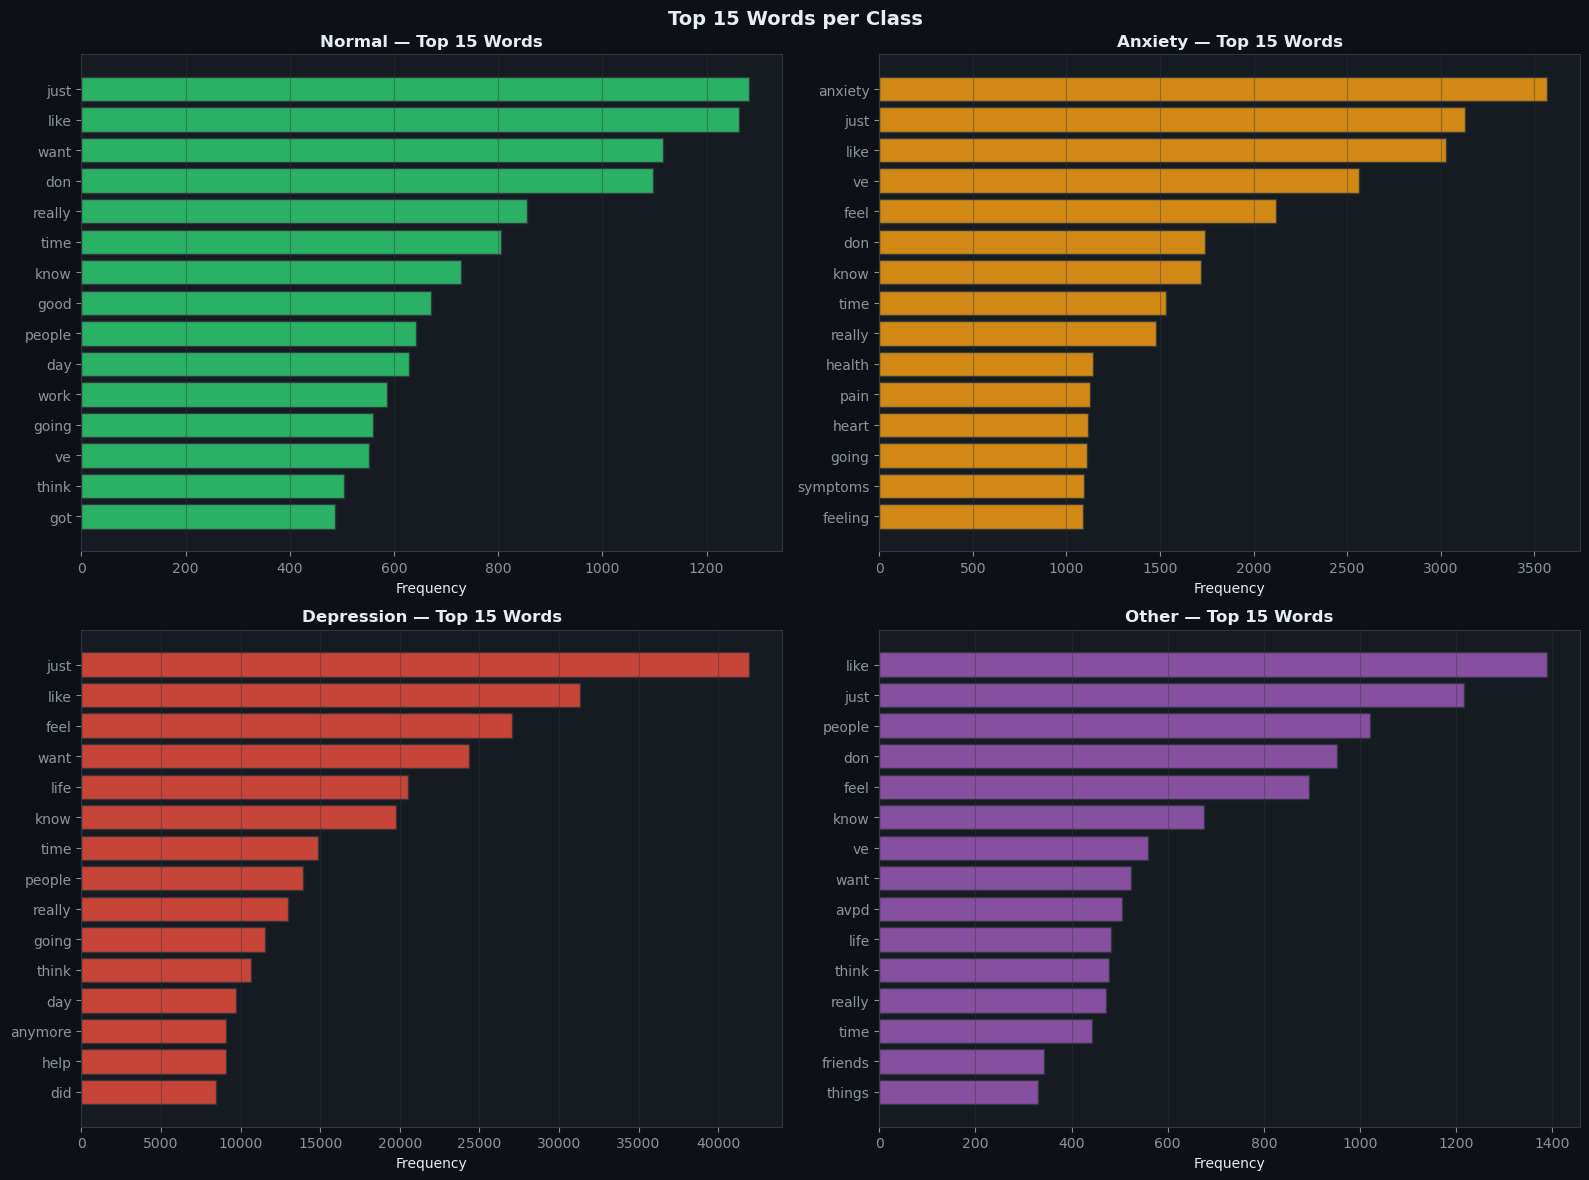

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top 15 Words per Class', fontsize=14, fontweight='bold')

stop_words = 'english'

for ax, cls, color in zip(axes.flat, CLASSES, PALETTE):
    texts = df[df['label'] == cls]['clean_text'].tolist()
    cv = CountVectorizer(stop_words=stop_words, max_features=15)
    cv.fit(texts)
    counts = np.asarray(cv.transform(texts).sum(axis=0)).flatten()
    words  = cv.get_feature_names_out()
    order  = np.argsort(counts)[::-1]
    ax.barh(words[order][::-1], counts[order][::-1], color=color, alpha=0.85, edgecolor='#30363d')
    ax.set_title(f'{cls} — Top 15 Words', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.grid(axis='x')

plt.tight_layout()
plt.savefig('word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Word Clouds per Class

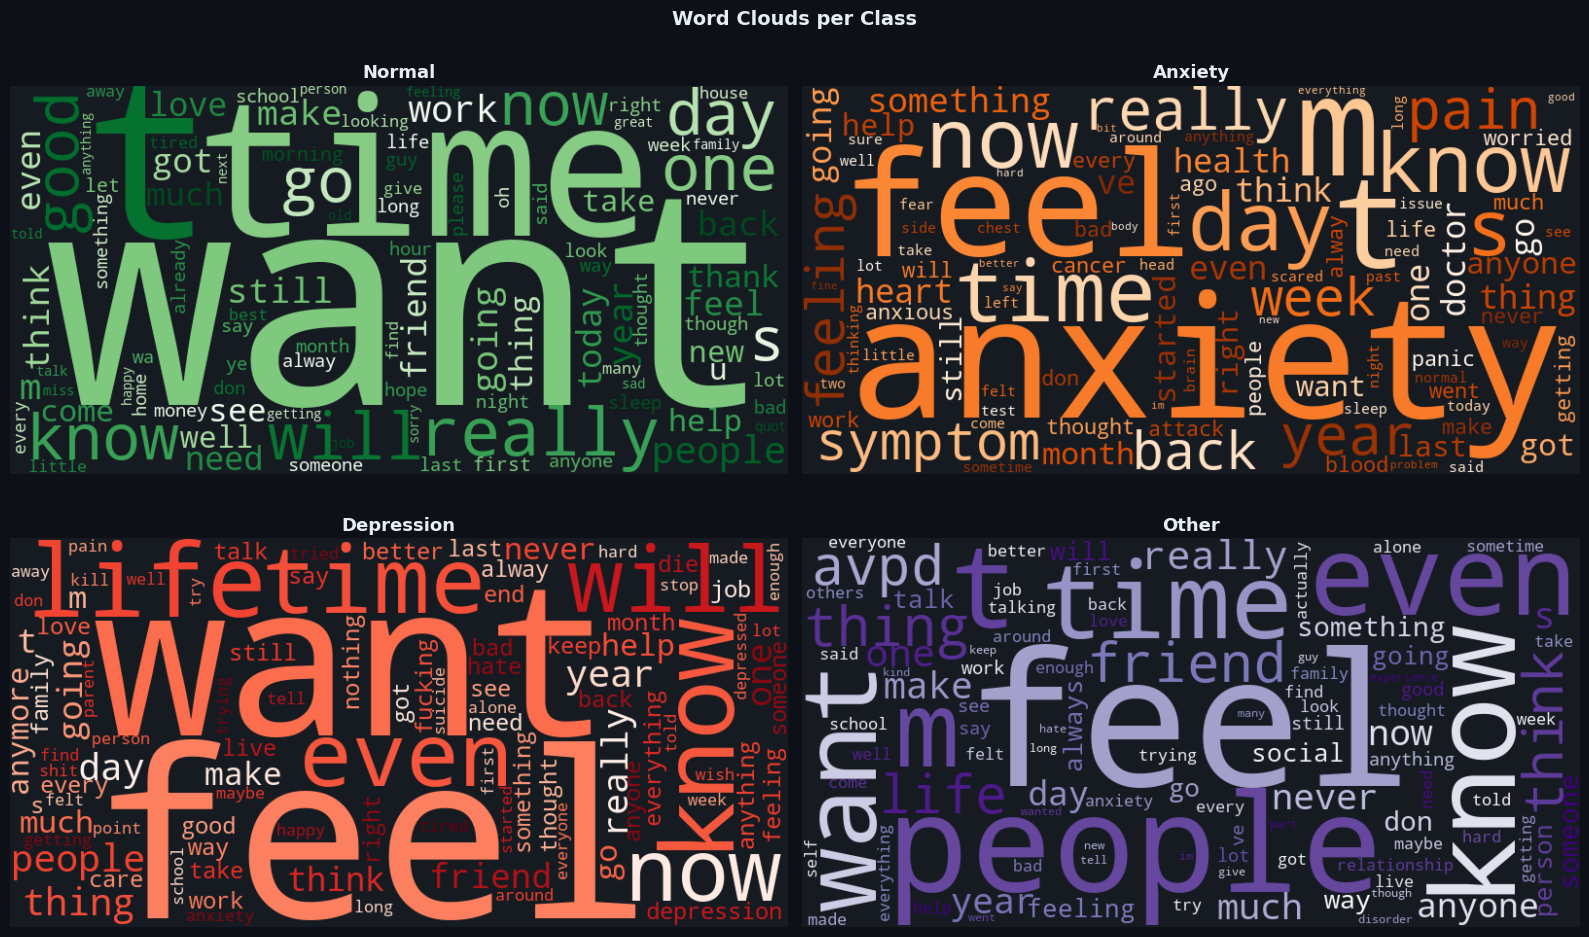

In [12]:
from wordcloud import WordCloud, STOPWORDS

wc_colors = {
    'Normal':     'Greens',
    'Anxiety':    'Oranges',
    'Depression': 'Reds',
    'Other':      'Purples',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Word Clouds per Class', fontsize=14, fontweight='bold')

for ax, cls in zip(axes.flat, CLASSES):
    text = ' '.join(df[df['label'] == cls]['clean_text'].tolist())
    wc = WordCloud(
        width=800, height=400,
        background_color='#161b22',
        colormap=wc_colors[cls],
        stopwords=STOPWORDS,
        max_words=100,
        collocations=False,
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cls, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Class Imbalance Analysis & Strategy

In [13]:
from data_preprocessing import encode_labels, split_data, compute_class_weights

df2, le = encode_labels(df.copy())
train_df, test_df = split_data(df2)
cw = compute_class_weights(train_df['label_enc'].values, num_classes=4)

print('=== Imbalance Summary ===')
print(f'Most common: {df["label"].value_counts().idxmax()} ({df["label"].value_counts().max():,})')
print(f'Least common: {df["label"].value_counts().idxmin()} ({df["label"].value_counts().min():,})')
ratio = df['label'].value_counts().max() / df['label'].value_counts().min()
print(f'Imbalance ratio: {ratio:.2f}:1')
print(f'\nClass weights (for training): {cw}')
print('\nStrategy: class_weight parameter in model.fit() — no SMOTE needed.')

2026-04-17 10:36:45,814 [INFO] Train size: 40850  |  Test size: 10213
2026-04-17 10:36:45,832 [INFO] Class weights: {0: 0.7962962962962963, 1: 3.528852798894264, 2: 0.4182879377431907, 3: 14.263268156424582}


=== Imbalance Summary ===
Most common: Depression (30,519)
Least common: Other (895)
Imbalance ratio: 34.10:1

Class weights (for training): {0: 0.7962962962962963, 1: 3.528852798894264, 2: 0.4182879377431907, 3: 14.263268156424582}

Strategy: class_weight parameter in model.fit() — no SMOTE needed.


## 8. Correlation of Text Length vs Class

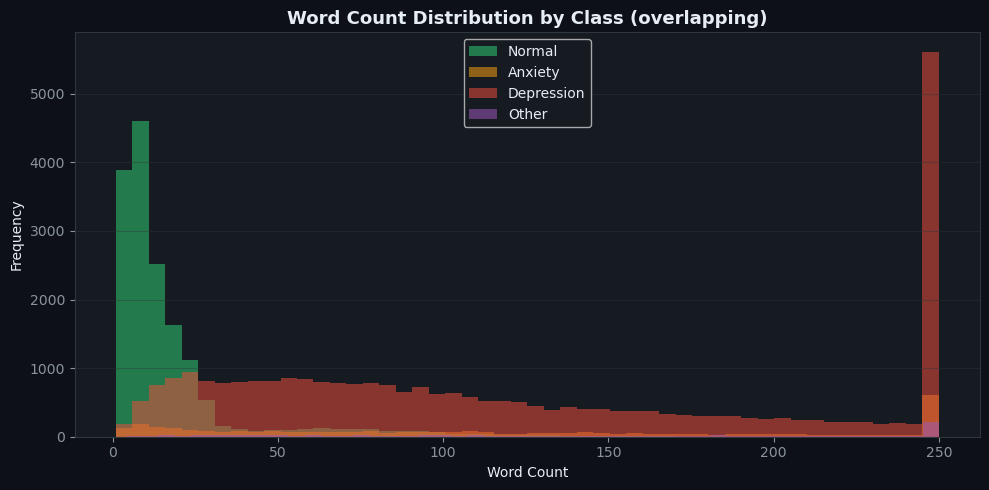

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
for cls, color in zip(CLASSES, PALETTE):
    subset = df[df['label'] == cls]['word_count'].clip(upper=250)
    ax.hist(subset, bins=50, alpha=0.55, color=color, label=cls, edgecolor='none')
ax.set_title('Word Count Distribution by Class (overlapping)', fontsize=13, fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('length_vs_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. EDA Summary

| Metric | Value |
|---|---|
| Total records (post-clean) | ~52,000 |
| Classes | Normal, Anxiety, Depression, Other |
| Dominant class | Normal |
| Missing text (original) | 362 rows (removed) |
| Avg word count | ~30–60 words |
| Imbalance strategy | class_weight in Keras |